# **Taller Práctico 03 — Inteligencia Geo-Temporal y de Redes**

## Optimización de Activos Críticos

**Maestría en Ciencia de Datos y Analítica — Universidad EAFIT**  
Curso: Fundamentos en Ciencia de Datos | Docente: Jorge Iván Padilla-Buriticá
Periodo académico 2026-2 

## Fase 1: Data Understanding y Geo-Visualización

### Tarea 1: Exploración Geo-Temporal

In [21]:
import pandas as pd 
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from scipy import signal
import networkx as nx


In [3]:
## Carga datos

df_agro = pd.read_csv(r'..\data\raw\agro\agro_clean.csv')
df_ener = pd.read_csv(r'..\data\raw\ener\ener_clean.csv')
df_agro

,Agro_1,Agro_2,Agro_3,Agro_4,Agro_5,Agro_6,Agro_7,Agro_8,Agro_9,Agro_10,Latitude,Longitude,Source_Node,Target_Node
0,60.248357,47.797447,65.395554,0.000000,0.478718,2.498349,10.000000,6.432151,1.258741,4.663639,6.203680,-75.400366,4,17
1,60.080940,48.076702,66.143237,25.002075,0.467100,2.473166,10.006672,6.469450,1.106051,4.683748,6.282310,-75.474525,14,21
2,60.623974,48.002378,66.342755,49.941596,0.449259,2.464547,10.013349,6.440262,1.183610,8.353141,6.165190,-75.476937,14,22
3,61.211672,48.267738,66.826015,74.756163,0.439299,2.500284,10.020030,6.511042,1.197917,6.213966,6.131334,-75.468152,8,25
4,60.483063,47.912028,65.703353,99.383693,0.436016,2.564177,10.026716,6.619718,1.200795,8.720976,6.241746,-75.349805,5,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,73.973383,58.759183,80.902167,0.000000,2.252759,2.893555,37.835599,6.381881,1.230914,5.705589,6.244438,-75.388452,11,16
1996,73.491049,58.180104,81.661594,0.000000,2.260299,2.793638,37.860844,6.492718,1.220833,6.785542,6.270976,-75.430809,14,27
1997,73.128022,58.759078,80.073673,0.000000,2.244597,2.758372,37.886105,6.583801,1.180722,4.575810,6.177446,-75.416718,4,21
1998,73.550718,59.398815,81.323042,0.000000,2.278655,2.783160,37.911384,6.489930,1.209546,5.982033,6.122933,-75.340495,13,22


In [31]:
df_ener

,Ener_1,Ener_2,Ener_3,Ener_4,Ener_5,Ener_6,Ener_7,Ener_8,Ener_9,Ener_10,...,Ener_2_Media_Movil,Ener_2_Varianza_Movil,Ener_3_Media_Movil,Ener_3_Varianza_Movil,Ener_5_Media_Movil,Ener_5_Varianza_Movil,Ener_6_Media_Movil,Ener_6_Varianza_Movil,Ener_7_Media_Movil,Ener_7_Varianza_Movil
0,117.538413,169.976747,31.052273,40.000000,5.035559,999.997980,500.382001,60.007129,109.525783,0.952104,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,123.085137,178.287791,30.367913,40.001201,4.964209,1000.012288,499.156777,60.010171,109.396517,0.963803,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,122.444639,178.064846,29.483741,40.004804,4.885030,1000.185140,499.276252,59.998643,110.560808,0.939290,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,117.595897,175.257364,29.985873,40.010804,5.039720,1000.075905,499.093300,59.994357,109.234773,0.945306,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,123.471177,186.082293,30.359202,40.019198,5.046006,999.714688,499.380771,59.955593,110.202660,0.951658,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,86.323567,128.336394,22.475277,22.051886,26.150812,803.439528,540.589156,60.005521,109.382291,0.946502,...,128.426256,25.240663,21.263503,0.367364,25.554799,0.094584,804.791224,1.505728,539.296440,0.954288
1996,91.342886,132.183280,21.312438,22.297509,26.168797,803.378768,539.852136,59.981609,111.213778,0.947118,...,128.665588,24.094825,21.279322,0.355922,25.574788,0.098838,804.720406,1.448870,539.343447,0.892603
1997,87.557997,137.318341,22.037410,22.551272,26.154045,803.187891,539.885870,59.974251,109.738614,0.946081,...,128.943175,24.986663,21.317696,0.338658,25.596913,0.099518,804.648093,1.402904,539.386241,0.844674
1998,92.630345,129.440422,22.130496,22.813095,26.140720,803.124892,540.535321,59.974938,110.126092,0.948870,...,129.021106,24.749689,21.355765,0.326386,25.613642,0.103520,804.576388,1.358231,539.419582,0.865010


In [36]:
((df_ener['Ener_5'] * df_ener['Ener_6'])/10) - df_ener['Ener_7']

0          3.172843
1         -2.729798
2        -10.682848
3          4.917003
4          5.075874
           ...     
1995    1560.470411
1996    1562.493450
1997    1560.775364
1998    1558.890997
1999    1558.076901
Length: 2000, dtype: float64

In [ ]:
cols_agro = {
    'Agro_1' : 'Humedad', 
    'Agro_2' : 'Evaporacion', 
    'Agro_3' : 'RH', 
    'Agro_4' : 'Radiacion PAR', 
    'Agro_5' : 'NVDI', 
    'Agro_6' : 'Biomasa', 
    #'Agro_7' : '',
    'Agro_8' : 'Ruido', 
    #'Agro_9' : '', 
    'Agro_10' : 'Varianza Viento'
}


cols_ener = {
    'Ener_1' : 'Demanda', 
    'Ener_2' : 'Precio', 
    'Ener_3' : 'Temperatura', 
    'Ener_4' : 'Gen. Eolica', 
    'Ener_5' : 'Costo Gas', 
    'Ener_6' : 'Emisiones CO2', 
 #   'Ener_7' : '',
    'Ener_8' : 'Frecuencia', 
    'Ener_9' : 'Voltaje', 
    'Ener_10' : 'Potencia'
}




Index(['Agro_1', 'Agro_2', 'Agro_3', 'Agro_4', 'Agro_5', 'Agro_6', 'Agro_7',
       'Agro_8', 'Agro_9', 'Agro_10', 'Latitude', 'Longitude', 'Source_Node',
       'Target_Node'],
      dtype='object')

In [4]:
##*scatter_mapbox* is deprecated! Use *scatter_map* instead

In [5]:
fig = px.scatter_map(
    df_agro, 
    lat="Latitude", 
    lon="Longitude",
    color="Agro_5", 
    size="Agro_1",
    zoom=10,
    # title="Scatter Map"
)

# Apply free map tile layers so you do not need a token
# fig.update_layout(mapbox_style="open-street-map")
fig.show()

Análisis: ¿Existe algún patrón espacial (clustering) donde la biomasa sea consistentemente baja?

### Tarea 2: Análisis de Estacionariedad y Windowing

In [6]:
df_ener

,Ener_1,Ener_2,Ener_3,Ener_4,Ener_5,Ener_6,Ener_7,Ener_8,Ener_9,Ener_10,Latitude,Longitude,Source_Node,Target_Node
0,117.538413,169.976747,31.052273,40.000000,5.035559,999.997980,500.382001,60.007129,109.525783,0.952104,6.772983,-75.450170,106,244
1,123.085137,178.287791,30.367913,40.001201,4.964209,1000.012288,499.156777,60.010171,109.396517,0.963803,6.817829,-76.987525,113,241
2,122.444639,178.064846,29.483741,40.004804,4.885030,1000.185140,499.276252,59.998643,110.560808,0.939290,5.519644,-73.757957,105,233
3,117.595897,175.257364,29.985873,40.010804,5.039720,1000.075905,499.093300,59.994357,109.234773,0.945306,8.788327,-73.611230,105,237
4,123.471177,186.082293,30.359202,40.019198,5.046006,999.714688,499.380771,59.955593,110.202660,0.951658,8.450681,-73.456254,108,206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,86.323567,128.336394,22.475277,22.051886,26.150812,803.439528,540.589156,60.005521,109.382291,0.946502,8.456787,-72.453955,106,218
1996,91.342886,132.183280,21.312438,22.297509,26.168797,803.378768,539.852136,59.981609,111.213778,0.947118,5.128314,-76.623466,106,249
1997,87.557997,137.318341,22.037410,22.551272,26.154045,803.187891,539.885870,59.974251,109.738614,0.946081,8.901269,-74.100966,116,208
1998,92.630345,129.440422,22.130496,22.813095,26.140720,803.124892,540.535321,59.974938,110.126092,0.948870,10.001202,-72.309228,106,224


In [7]:
adf_results = []
non_stationary_cols = []

for col in df_ener.columns:
    series = df_ener[col].dropna()
    
    # Test ADF con selección automática de rezagos basada en AIC
    stat, p_value, usedlag, nobs, crit_vals, icbest = adfuller(series, autolag='AIC')
    
    is_stationary = p_value < 0.05
    if not is_stationary:
        non_stationary_cols.append(col)
        
    adf_results.append({
        'Serie': col,
        'Estadístico ADF': round(stat, 4),
        'p-valor': p_value,
        'Valor Crítico (5%)': round(crit_vals['5%'], 4),
        'Estacionaria': 'Sí' if is_stationary else 'No'
    })

# Convertir resultados a DataFrame
df_adf_summary = pd.DataFrame(adf_results)
print("--- RESULTADOS TEST ADF ---")
print(df_adf_summary.to_string(index=False))

--- RESULTADOS TEST ADF ---
      Serie  Estadístico ADF  p-valor  Valor Crítico (5%) Estacionaria
     Ener_1    -1.866900e+00 0.347793              -2.863           No
     Ener_2    -1.479100e+00 0.543807              -2.863           No
     Ener_3    -1.928400e+00 0.318802              -2.863           No
     Ener_4    -1.336821e+10 0.000000              -2.863           Sí
     Ener_5    -3.477000e-01 0.918470              -2.863           No
     Ener_6     9.527000e-01 0.993741              -2.863           No
     Ener_7    -4.244000e-01 0.905937              -2.863           No
     Ener_8    -4.603630e+01 0.000000              -2.863           Sí
     Ener_9    -4.535820e+01 0.000000              -2.863           Sí
    Ener_10    -4.371510e+01 0.000000              -2.863           Sí
   Latitude    -4.500980e+01 0.000000              -2.863           Sí
  Longitude    -4.413750e+01 0.000000              -2.863           Sí
Source_Node    -4.536900e+01 0.000000            

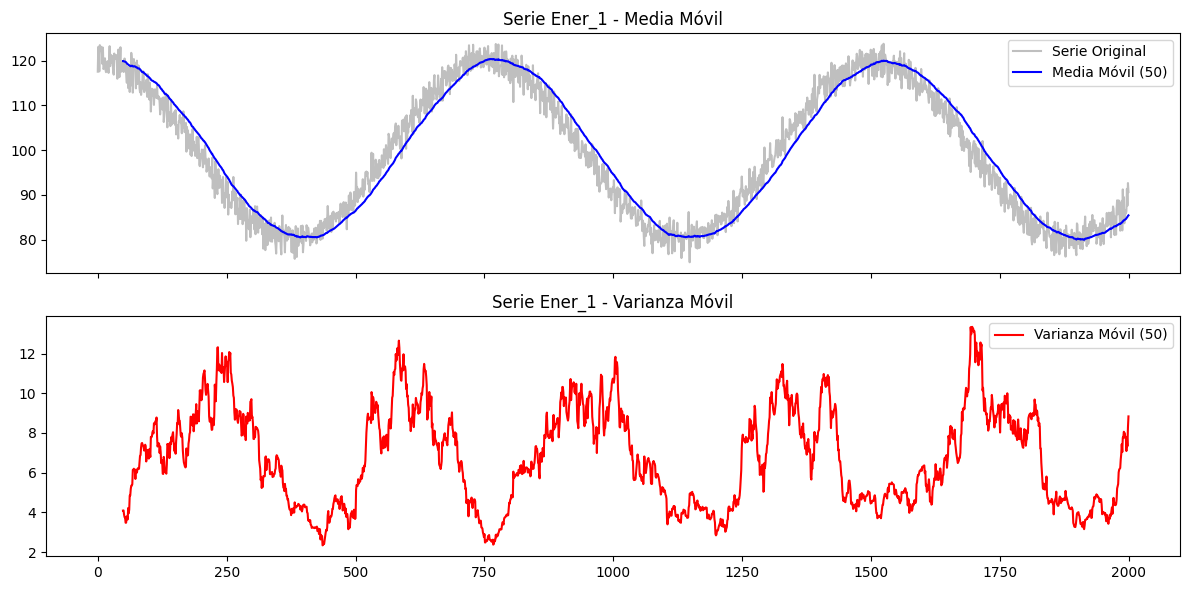

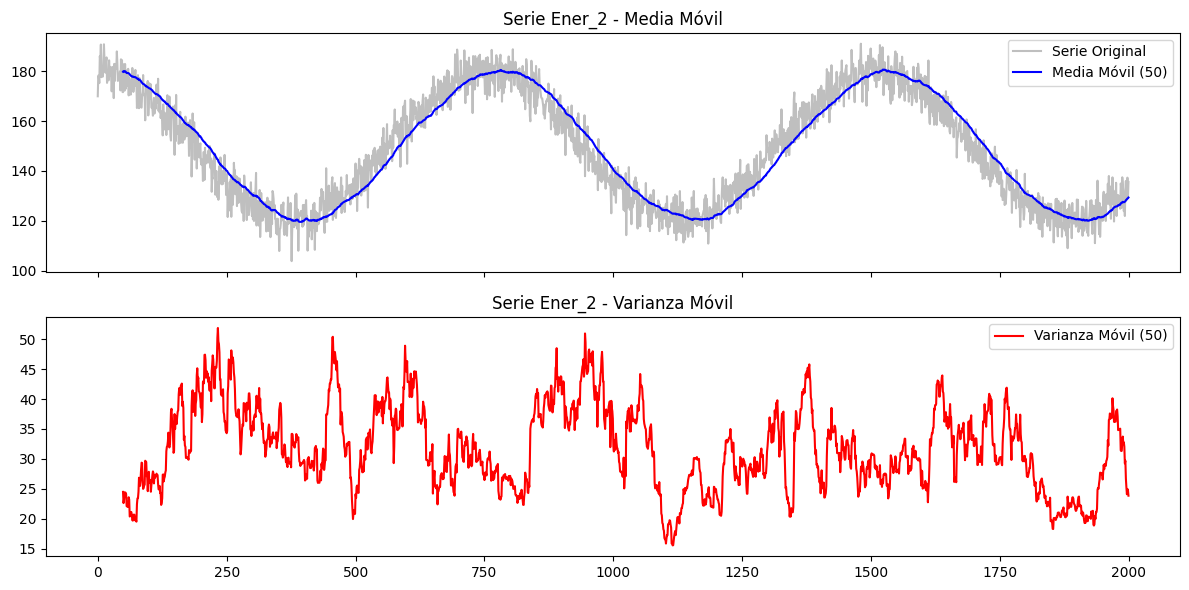

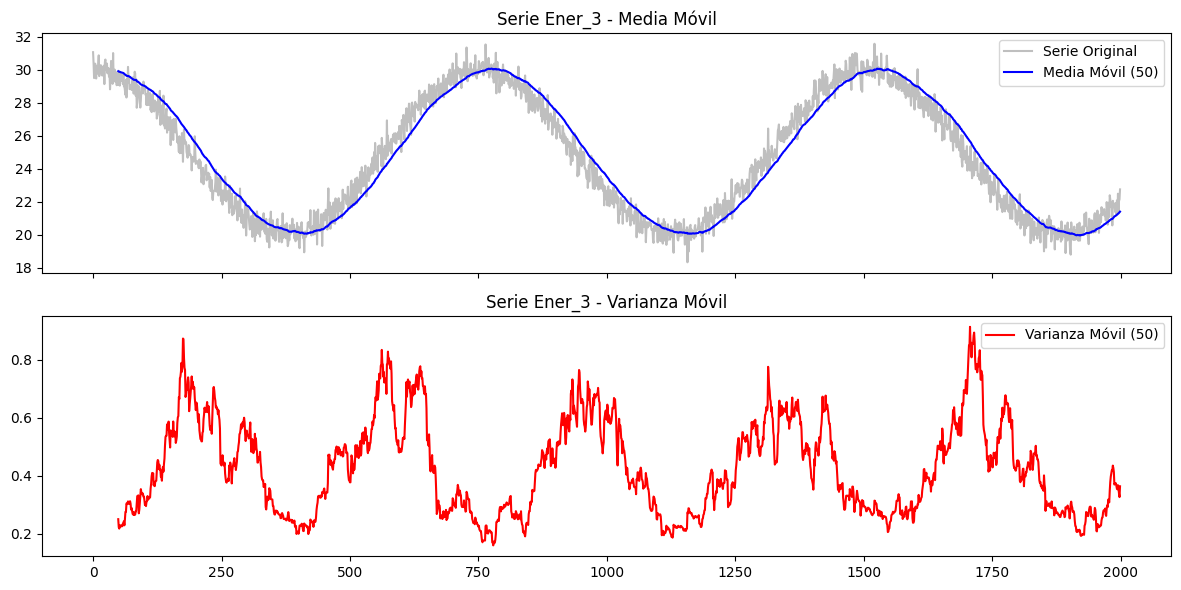

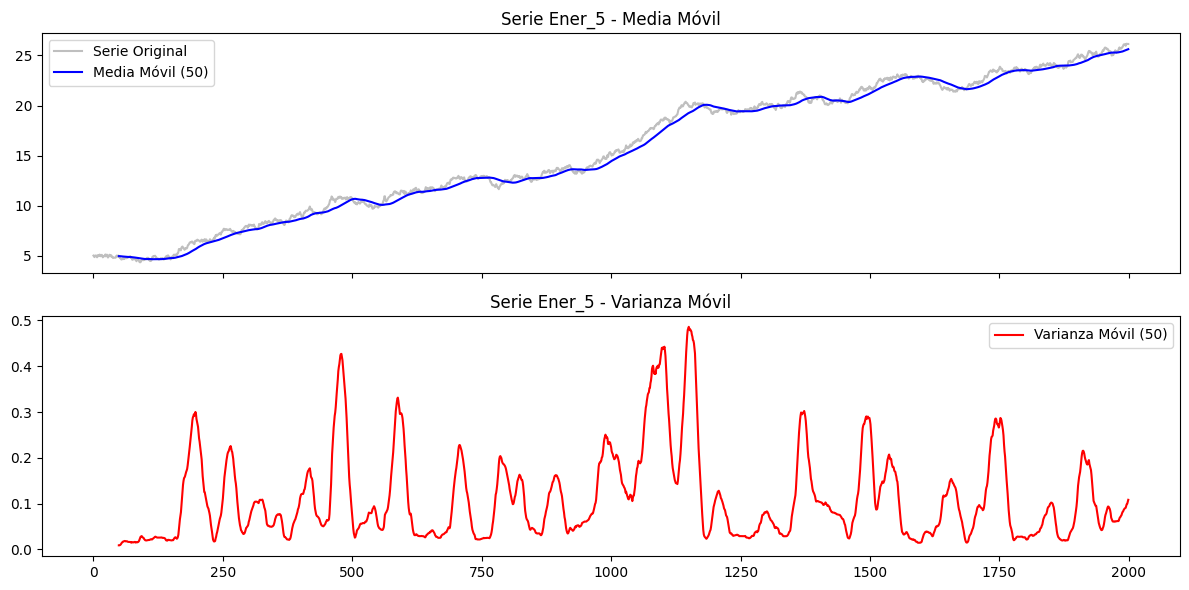

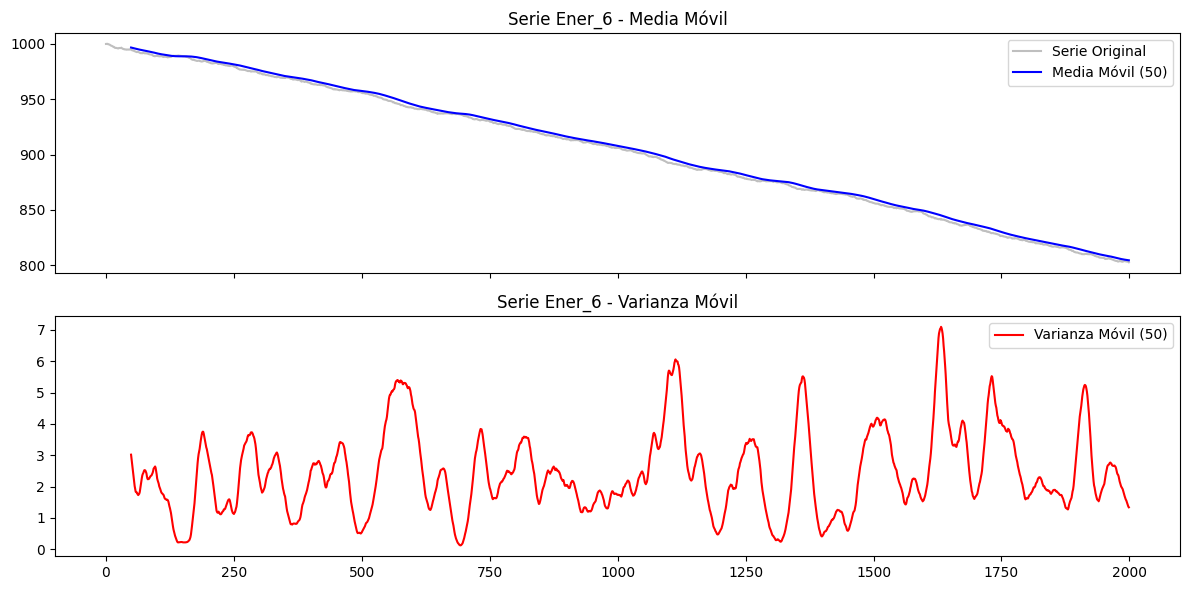

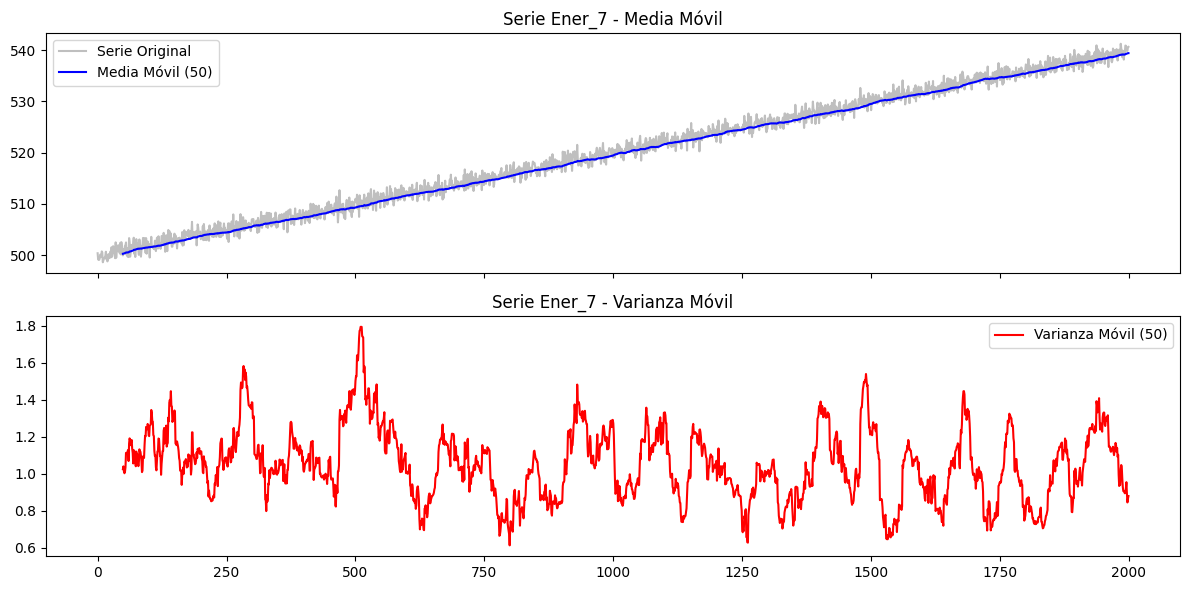

In [8]:
window_size = 50

if len(non_stationary_cols) > 0:
    for col in non_stationary_cols:
        df_ener[f'{col}_Media_Movil'] = df_ener[col].rolling(window=window_size).mean()
        df_ener[f'{col}_Varianza_Movil'] = df_ener[col].rolling(window=window_size).var()
        
        # Graficar media y varianza móvil
        fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
        
        ax[0].plot(df_ener[col], label='Serie Original', color='gray', alpha=0.5)
        ax[0].plot(df_ener[f'{col}_Media_Movil'], label=f'Media Móvil ({window_size})', color='blue')
        ax[0].set_title(f'Serie {col} - Media Móvil')
        ax[0].legend()
        
        ax[1].plot(df_ener[f'{col}_Varianza_Movil'], label=f'Varianza Móvil ({window_size})', color='red')
        ax[1].set_title(f'Serie {col} - Varianza Móvil')
        ax[1].legend()
        
        plt.tight_layout()
        plt.show()
else:
    print("Todas las series resultaron ser estacionarias al nivel alpha = 0.05.")

--- PRUEBAS ESPECÍFICAS ADF EN ENER_5 ---
Sin constante (n): Estadístico = 4.1696, p-valor = 1.0000e+00
Con Drift (c):     Estadístico = -0.3477, p-valor = 9.1847e-01
Con Tendencia (ct):Estadístico = -2.3625, p-valor = 3.9974e-01

Media de las primeras diferencias (Drift estimado): 0.010560


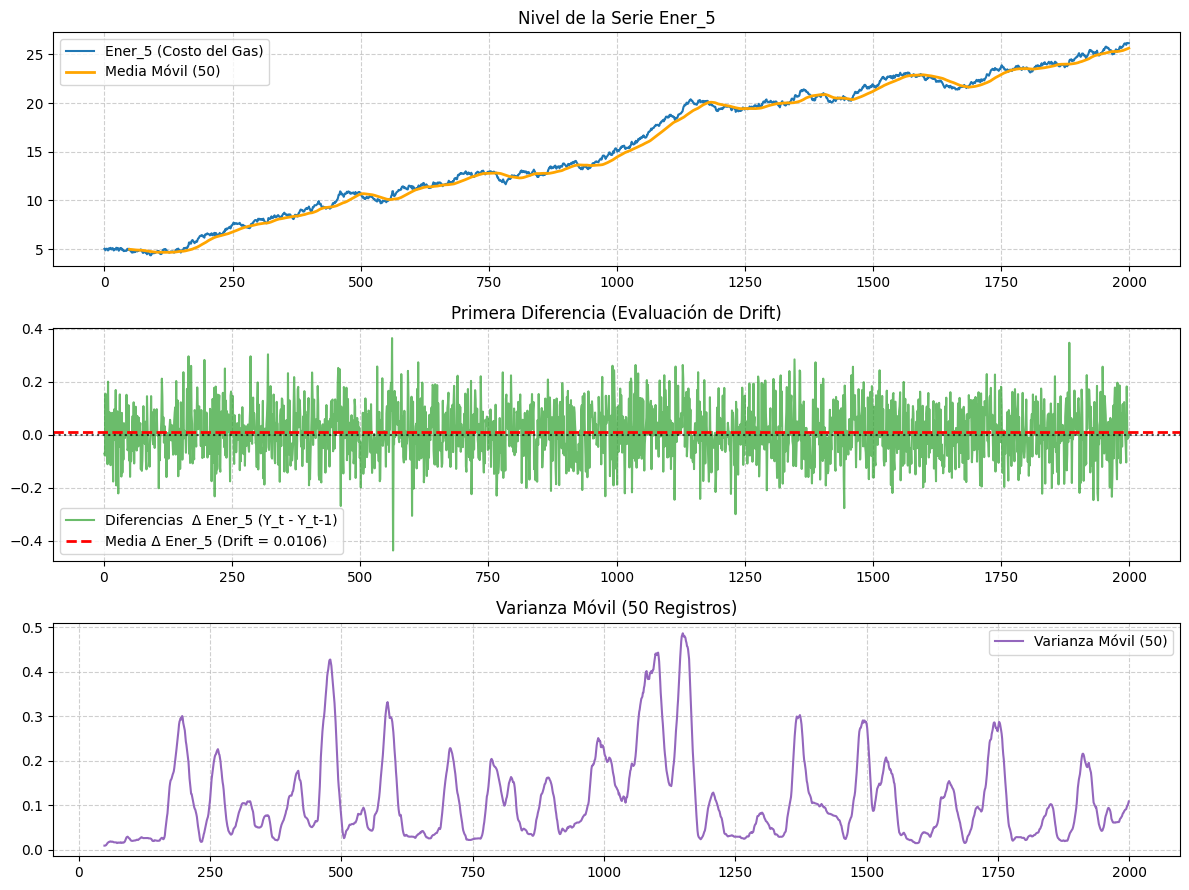

In [9]:
ener5 = df_ener['Ener_5'].dropna()
diff_ener5 = ener5.diff().dropna()

# 1. Ajuste de especificaciones ADF para Ener_5
res_n = adfuller(ener5, regression='n')   # Sin constante (Pure Random Walk)
res_c = adfuller(ener5, regression='c')   # Con constante/drift
res_ct = adfuller(ener5, regression='ct') # Con constante y tendencia lineal

print("--- PRUEBAS ESPECÍFICAS ADF EN ENER_5 ---")
print(f"Sin constante (n): Estadístico = {res_n[0]:.4f}, p-valor = {res_n[1]:.4e}")
print(f"Con Drift (c):     Estadístico = {res_c[0]:.4f}, p-valor = {res_c[1]:.4e}")
print(f"Con Tendencia (ct):Estadístico = {res_ct[0]:.4f}, p-valor = {res_ct[1]:.4e}")

mean_diff = diff_ener5.mean()
print(f"\nMedia de las primeras diferencias (Drift estimado): {mean_diff:.6f}")

# 2. Visualización
fig, axes = plt.subplots(3, 1, figsize=(12, 9))

# Subplot 1: Serie Ener_5 y Media Móvil (50)
axes[0].plot(ener5, color='tab:blue', label='Ener_5 (Costo del Gas)')
axes[0].plot(ener5.rolling(50).mean(), color='orange', linewidth=2, label='Media Móvil (50)')
axes[0].set_title('Nivel de la Serie Ener_5')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Subplot 2: Primeras Diferencias (Δ Ener_5) y su Drift Estimado
axes[1].plot(diff_ener5, color='tab:green', alpha=0.7, label='Diferencias  Δ Ener_5 (Y_t - Y_t-1)')
axes[1].axhline(mean_diff, color='red', linestyle='--', linewidth=2, label=f'Media Δ Ener_5 (Drift = {mean_diff:.4f})')
axes[1].axhline(0, color='black', linestyle=':', alpha=0.7)
axes[1].set_title('Primera Diferencia (Evaluación de Drift)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

# Subplot 3: Varianza Móvil (50) de la Serie en Nivel
axes[2].plot(ener5.rolling(50).var(), color='tab:purple', label='Varianza Móvil (50)')
axes[2].set_title('Varianza Móvil (50 Registros)')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Fase 2: Procesamiento de Señales y Filtrado


### Tarea 3: Análisis Espectral (FFT) y Espectrogramas

In [ ]:
N = len(df_ener['Ener_4'])
fs = 1.0

2000

In [ ]:
snr_db = 8.0  # Seleccionado dentro de [5, 12] dB

# Potencia media de la señal eólica limpia
p_signal = np.mean(df_ener['Ener_4']**2)

# Potencia del ruido derivada de la relación SNR: SNR = 10 * log10(P_signal / P_noise)
p_noise = p_signal / (10 ** (snr_db / 10.0))
noise_std = np.sqrt(p_noise)

# Generación del ruido gaussiano
np.random.seed(42)  # Para reproducibilidad
noise = np.random.normal(0, noise_std, size=N)

# Serie con ruido inyectado
ener4_noise = df_ener['Ener_4'] + noise

print(f"Potencia de la Señal: {p_signal:.2f}")
print(f"Potencia del Ruido (8 dB): {p_noise:.2f} (Desviación estándar: {noise_std:.2f})")

Potencia de la Señal: 1766.52
Potencia del Ruido (8 dB): 279.97 (Desviación estándar: 16.73)


In [15]:
# Frecuencias asociadas a la FFT (rango Nyquist [0, 0.5])
freqs = np.fft.rfftfreq(N, d=1/fs)

# Transformada de Fourier
fft_clean = np.fft.rfft(df_ener['Ener_4'])
fft_noise = np.fft.rfft(ener4_noise)

# Densidad Espectral de Potencia (PSD)
psd_clean = (np.abs(fft_clean)**2) / (N * fs)
psd_noise = (np.abs(fft_noise)**2) / (N * fs)

In [ ]:

nperseg = 128
noverlap = 64

# Espectrogramas para la serie limpia y ruidosa
f_clean, t_clean, Sxx_clean = signal.spectrogram(df_ener['Ener_4'], fs=fs, nperseg=nperseg, noverlap=noverlap)
f_noise, t_noise, Sxx_noise = signal.spectrogram(ener4_noise, fs=fs, nperseg=nperseg, noverlap=noverlap)

# Diferencia espectral en escala decibélica (dB)
diff_spec = 10 * np.log10(Sxx_noise + 1e-12) - 10 * np.log10(Sxx_clean + 1e-12)

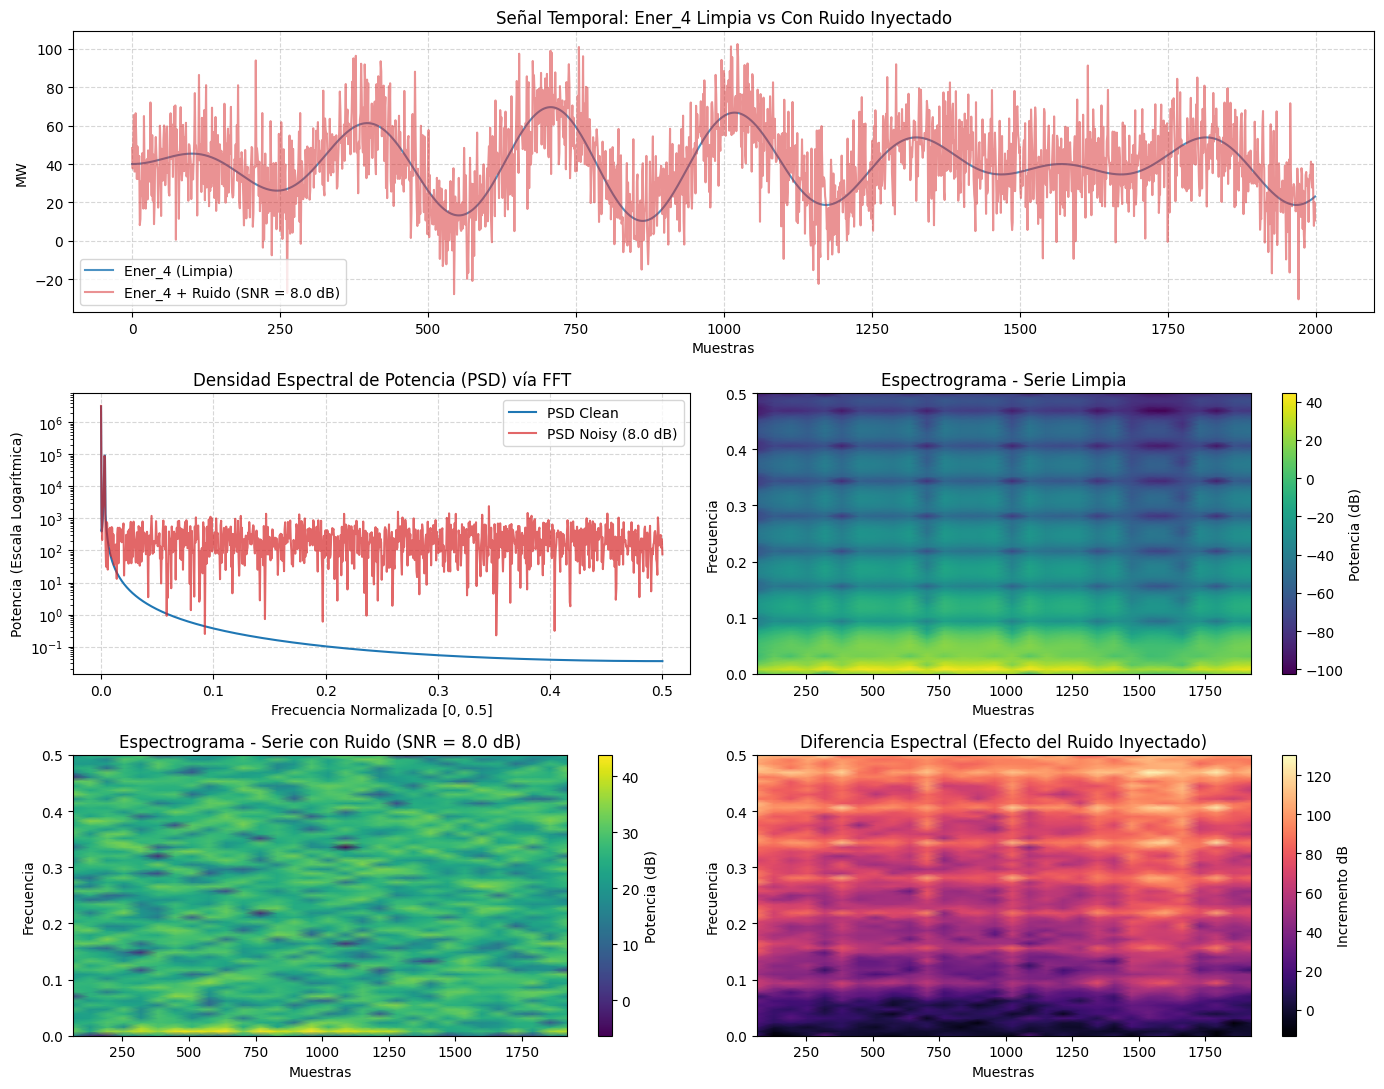

In [18]:
fig = plt.figure(figsize=(14, 11))

# 1. Señal Temporal
ax1 = plt.subplot(3, 2, (1, 2))
ax1.plot(df_ener['Ener_4'], label='Ener_4 (Limpia)', color='tab:blue', alpha=0.8)
ax1.plot(ener4_noise, label=f'Ener_4 + Ruido (SNR = {snr_db} dB)', color='tab:red', alpha=0.5)
ax1.set_title('Señal Temporal: Ener_4 Limpia vs Con Ruido Inyectado')
ax1.set_xlabel('Muestras')
ax1.set_ylabel('MW')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# 2. Densidad Espectral de Potencia (PSD)
ax2 = plt.subplot(3, 2, 3)
ax2.semilogy(freqs, psd_clean, label='PSD Clean', color='tab:blue')
ax2.semilogy(freqs, psd_noise, label=f'PSD Noisy ({snr_db} dB)', color='tab:red', alpha=0.7)
ax2.set_title('Densidad Espectral de Potencia (PSD) vía FFT')
ax2.set_xlabel('Frecuencia Normalizada [0, 0.5]')
ax2.set_ylabel('Potencia (Escala Logarítmica)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

# 3. Espectrograma Clean
ax3 = plt.subplot(3, 2, 4)
pcm1 = ax3.pcolormesh(t_clean, f_clean, 10 * np.log10(Sxx_clean + 1e-12), shading='gouraud', cmap='viridis')
fig.colorbar(pcm1, ax=ax3, label='Potencia (dB)')
ax3.set_title('Espectrograma - Serie Limpia')
ax3.set_xlabel('Muestras')
ax3.set_ylabel('Frecuencia')

# 4. Espectrograma Noisy
ax4 = plt.subplot(3, 2, 5)
pcm2 = ax4.pcolormesh(t_noise, f_noise, 10 * np.log10(Sxx_noise + 1e-12), shading='gouraud', cmap='viridis')
fig.colorbar(pcm2, ax=ax4, label='Potencia (dB)')
ax4.set_title(f'Espectrograma - Serie con Ruido (SNR = {snr_db} dB)')
ax4.set_xlabel('Muestras')
ax4.set_ylabel('Frecuencia')

# 5. Diferencia Espectral (Efecto del ruido)
ax5 = plt.subplot(3, 2, 6)
pcm3 = ax5.pcolormesh(t_noise, f_noise, diff_spec, shading='gouraud', cmap='magma')
fig.colorbar(pcm3, ax=ax5, label='Incremento dB')
ax5.set_title('Diferencia Espectral (Efecto del Ruido Inyectado)')
ax5.set_xlabel('Muestras')
ax5.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Tarea 4: Filtrado y Reconstrucción


## Fase 3: Análisis de Grafos y Topología de Red


### Tarea 5: Construcción de la Red de Sensores/Subestaciones

In [23]:
G = nx.from_pandas_edgelist(
    df_agro,
    source="Source_Node",
    target="Target_Node",
    create_using=nx.DiGraph(),  # Especifica que es un Grafo Dirigido
)

# 2. Calcular la Centralidad de Grado (Degree Centrality)
# Para grafos dirigidos podemos calcular el grado total, de entrada y de salida
degree_cent = nx.degree_centrality(G)
in_degree_cent = nx.in_degree_centrality(G)
out_degree_cent = nx.out_degree_centrality(G)

# Calcular Betweenness Centrality (Centralidad de Intermediación)
betweenness_cent = nx.betweenness_centrality(G)

# 3. Integrar los resultados en un DataFrame para facilitar la consulta
metrics_df = pd.DataFrame(
    {
        "Degree_Centrality": pd.Series(degree_cent),
        "In_Degree_Centrality": pd.Series(in_degree_cent),
        "Out_Degree_Centrality": pd.Series(out_degree_cent),
        "Betweenness_Centrality": pd.Series(betweenness_cent),
    }
).sort_values(by="Betweenness_Centrality", ascending=False)

# 4. Resolver el Reto: Identificar el Nodo Cuello de Botella
# El cuello de botella corresponde al nodo con el valor más alto de Betweenness Centrality
bottleneck_node = metrics_df["Betweenness_Centrality"].idxmax()
bottleneck_value = metrics_df.loc[bottleneck_node, "Betweenness_Centrality"]

# Mostrar resultados principales
print(f"--- NODO CUELLO DE BOTELLA ---")
print(
    f"El nodo '{bottleneck_node}' es el cuello de botella con una Betweenness Centrality de {bottleneck_value:.4f}\n"
)

print("--- TOP 5 NODOS POR INTERMEDIACIÓN (BETWEENNESS) ---")
print(metrics_df.head())

--- NODO CUELLO DE BOTELLA ---
El nodo '4' es el cuello de botella con una Betweenness Centrality de 0.0000

--- TOP 5 NODOS POR INTERMEDIACIÓN (BETWEENNESS) ---
    Degree_Centrality  In_Degree_Centrality  Out_Degree_Centrality  \
4            0.535714                   0.0               0.535714   
17           0.500000                   0.5               0.000000   
14           0.535714                   0.0               0.535714   
21           0.500000                   0.5               0.000000   
22           0.500000                   0.5               0.000000   

    Betweenness_Centrality  
4                      0.0  
17                     0.0  
14                     0.0  
21                     0.0  
22                     0.0  


## Fase 4: Modelado y Toma de Decisiones (CRISP-DM)


### Problema de Negocio: La Falla del Nodo 214